In [29]:
%matplotlib inline

import mne
from mne.datasets import eegbci
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#matplotlib.use('Agg') #writes to files instead of window display
mne.set_log_level('WARNING')

In [30]:
#load subject
subject = 1
runs = [6, 10] #motor imagery: imagine left vs right hand
raw_files = eegbci.load_data(subject, runs)
raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_files])

print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [31]:
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Time: {raw.times[-1]:.1f} Seconds")

Channels: 64
Sampling rate: 160.0 Hz
Time: 250.0 Seconds


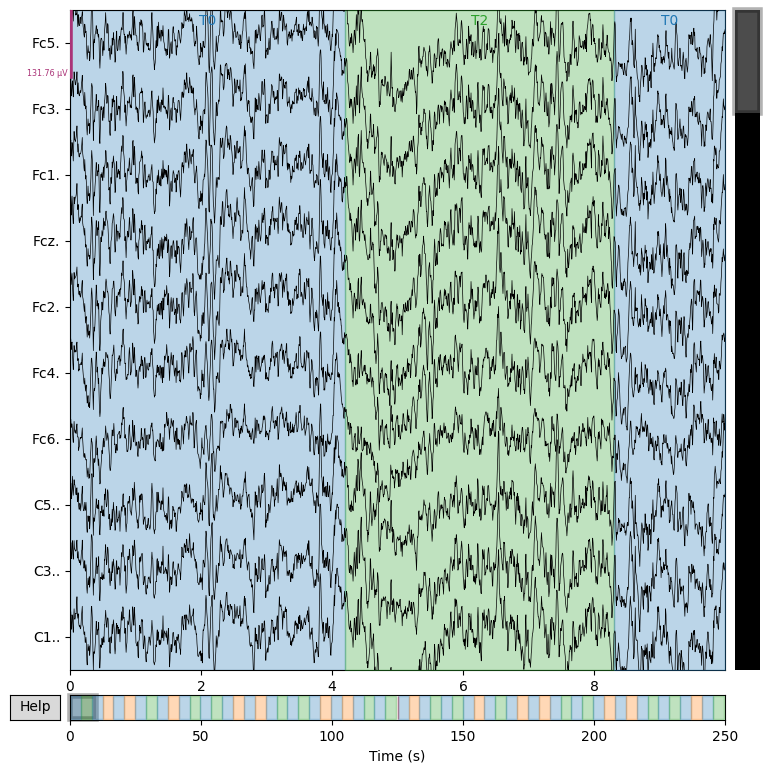

In [34]:
fig = raw.plot(n_channels=10, duration=10, scalings='auto', show=False)
plt.savefig('results/01_raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [36]:
events, event_id = mne.events_from_annotations(raw)

print(f"Event-Types: {event_id}")
print(f"Number of Events: {len(events)}")
print(f"\nFirst 10 Events (Sample, 0, Event-ID):")
print(events[:10])

#T0 (ID 1) = Pause / Standby
#T1 (ID 2) = Hold up your left fist
#T2 (ID 3) = Hold up your right fist

Event-Types: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Number of Events: 60

First 10 Events (Sample, 0, Event-ID):
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    2]]
